Сначала импортируем все нужные библиотеки

In [ ]:
!pip install rdkit
!pip install pandas numpy matplotlib seaborn scikit-learn requests tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 33.9 MB/s eta 0:00:00


In [ ]:
# Импорт библиотек
import requests
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

Теперь мы загружаем данные из химической базы данных Chemble для рецептора Chembl206

In [ ]:
url = ("https://www.ebi.ac.uk/chembl/api/data/activity.json?"
       "target_chembl_id=CHEMBL206&standard_type=Ki&standard_units=nM&limit=10000")

# Отправка GET-запроса к API ChEMBL
resp = requests.get(url)

# Проверка успешности запроса
if resp.status_code == 200:
    data = resp.json()['activities']
    print(f"Количество записей, выведенных из базы данных ChEMBL: {len(data)}")

    # Преобразование в DataFrame
    df = pd.DataFrame(data)
df

Количество записей, выведенных из базы данных ChEMBL: 876


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,147369,[],CHEMBL682298,Binding affinity for estrogen receptor alpha,B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,29.0
1,None,None,147372,[],CHEMBL682298,Binding affinity for estrogen receptor alpha,B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,1.7
2,None,None,148587,[],CHEMBL682298,Binding affinity for estrogen receptor alpha,B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,0.4
3,None,None,152133,[],CHEMBL682298,Binding affinity for estrogen receptor alpha,B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,170.0
4,None,None,154592,[],CHEMBL682298,Binding affinity for estrogen receptor alpha,B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,None,1273624,28990217,[],CHEMBL5739232,"ERalpha (Wild Type), ERalpha (Y537S Mutant) an...",B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,1.13
872,None,1273626,28990220,[],CHEMBL5739232,"ERalpha (Wild Type), ERalpha (Y537S Mutant) an...",B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,1.55
873,None,1273628,28990223,[],CHEMBL5739232,"ERalpha (Wild Type), ERalpha (Y537S Mutant) an...",B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,3.2
874,None,1273630,28990226,[],CHEMBL5739232,"ERalpha (Wild Type), ERalpha (Y537S Mutant) an...",B,None,None,BAO_0000192,...,Homo sapiens,Estrogen receptor,9606,None,None,Ki,nM,UO_0000065,None,9.33


Теперь сделаем предобработку нашего датасета

In [ ]:
# Выбор нужных колонок и очистка данных
processed_df = df[['molecule_chembl_id', 'canonical_smiles', 'standard_value']].copy()

# Удаление пропущенных значений
processed_df = processed_df.dropna()

# Преобразование в числовой формат и фильтрация некорректных значений
processed_df['standard_value'] = pd.to_numeric(processed_df['standard_value'], errors='coerce')
processed_df = processed_df.dropna(subset=['standard_value'])
processed_df = processed_df[processed_df['standard_value'] > 0]

# Преобразование Ki в pKi
processed_df['pValue'] = 9-np.log10(processed_df['standard_value'])

# Удаление дубликатов по SMILES
processed_df = processed_df.drop_duplicates(subset=['canonical_smiles'])
processed_df = processed_df.rename(columns={'canonical_smiles': 'smiles'})

print(f"После предобработки осталось {len(processed_df)} уникальных соединений")
processed_df

После предобработки осталось 700 уникальных соединений


,molecule_chembl_id,smiles,standard_value,pValue
0,CHEMBL59146,O=C(c1ccc(OCCN2CCCCC2)cc1)N1c2ccc(O)cc2CCC1c1c...,29.00,7.537602
1,CHEMBL60538,Oc1ccc2c(c1)CCC(c1ccccc1)N2Cc1ccc(OCCN2CCCCC2)cc1,1.70,8.769551
2,CHEMBL81,O=C(c1ccc(OCCN2CCCCC2)cc1)c1c(-c2ccc(O)cc2)sc2...,0.40,9.397940
3,CHEMBL293599,Oc1ccc(C2CCc3cc(O)ccc3N2)cc1,170.00,6.769551
4,CHEMBL56306,Oc1ccc(C2CCc3cc(O)ccc3N2Cc2ccc(OCCN3CCCC3)cc2)cc1,1.10,8.958607
...,...,...,...,...
804,CHEMBL5769467,Cc1cccc2c1OC(c1ccc(OCCN3CC(CF)C3)cc1)c1c-2cnc2...,3.20,8.494850
806,CHEMBL5797158,Cc1cccc2c1O[C@@H](c1ccc(OCCN3CC(CF)C3)cc1)c1c-...,9.33,8.030118
808,CHEMBL5751804,Cc1cccc2c1O[C@H](c1ccc(OCCN3CC(CF)C3)cc1)c1c-2...,0.94,9.026872
826,CHEMBL5816503,Oc1ccc2c3c(cnc2c1)-c1ccc(Cl)cc1O[C@@H]3c1ccc(O...,0.59,9.229148


теперь сгенерируем фингерпринты Моргана размером 1024 бита и радиусом 2

In [ ]:
# Генерация отпечатков Моргана (1024 бита, радиус=2)
print("Генерация молекулярных дескрипторов...")
fingerprints = []  # Список для хранения отпечатков
valid_indices = [] # Список для хранения индексов успешно обработанных молекул

for idx, smiles in enumerate(tqdm(processed_df['smiles'])):
    # Преобразуем SMILES в молекулярный объект RDKit
    mol = Chem.MolFromSmiles(smiles)

    # Если преобразование успешно
    if mol is not None:
        # Генерируем 1024-битный отпечаток Моргана с радиусом 2
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)

        # Сохраняем результаты
        fingerprints.append(fp)
        valid_indices.append(idx)

fp_array = np.array(fingerprints)
processed_df = processed_df.iloc[valid_indices].reset_index(drop=True)
print(f"Сгенерировано {fp_array.shape[0]} отпечатков")

# Удаление низковариативных признаков (дисперсия < 0.01)
selector = VarianceThreshold(threshold=0.01)
filtered_features = selector.fit_transform(fp_array)
print(f"Оставлено {filtered_features.shape[1]} из {fp_array.shape[1]} признаков после фильтрации")

Генерация молекулярных дескрипторов...


  0%|          | 0/700 [00:00<?, ?it/s][21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPRECATION WARNING: please use MorganGenerator
[21:37:29] DEPREC

Сгенерировано 700 отпечатков
Оставлено 570 из 1024 признаков после фильтрации


Чтобы избежать переобучения модели и при этом уменьшить вычислительные затраты, сделаем снижение размерности с помощью PCA

Выбрано 164 компонент, объясняющих ≥95% дисперсии


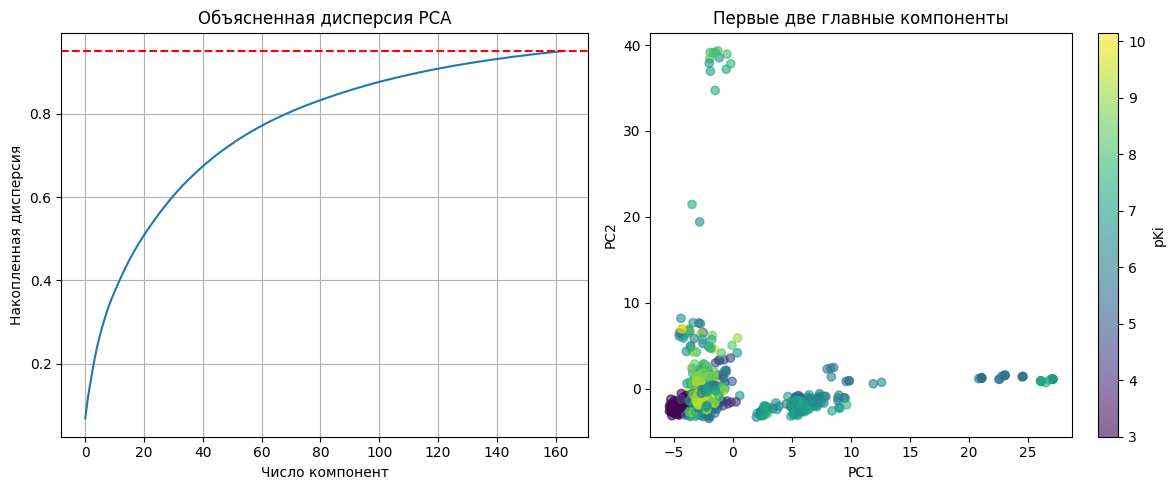

In [ ]:
# Стандартизация данных
scaler = StandardScaler()
scaled_features = scaler.fit_transform(filtered_features)

# Определение оптимального числа компонент (≥95% дисперсии)
pca = PCA().fit(scaled_features)
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(explained_variance >= 0.95) + 1

# Применение PCA
pca = PCA(n_components=n_components)
pca_features = pca.fit_transform(scaled_features)
print(f"Выбрано {n_components} компонент, объясняющих ≥95% дисперсии")

# Визуализация PCA
plt.figure(figsize=(12, 5))

# График объясненной дисперсии
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Число компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Объясненная дисперсия PCA')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.grid()

# Scatter plot первых двух компонент
plt.subplot(1, 2, 2)
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=processed_df['pValue'], cmap='viridis', alpha=0.6)
plt.colorbar(label='pKi')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Первые две главные компоненты')

plt.tight_layout()
plt.show()

На основании всей этой информации мы сформируем финальный датасет
final_datacet

In [ ]:
# Создание DataFrame с PCA компонентами
pca_columns = [f'pca_{i+1}' for i in range(pca_features.shape[1])]
pca_df = pd.DataFrame(pca_features, columns=pca_columns)

# Объединение всех данных
final_df = pd.concat([
    processed_df[['molecule_chembl_id', 'smiles', 'pValue']],
    pca_df
], axis=1)

# Сохранение в файл
final_df.to_csv('final_dataset.csv', index=False)
print("Финальный датасет сохранен в final_dataset.csv")

final_df.head()

Финальный датасет сохранен в final_dataset.csv


,molecule_chembl_id,smiles,pValue,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,...,pca_155,pca_156,pca_157,pca_158,pca_159,pca_160,pca_161,pca_162,pca_163,pca_164
0,CHEMBL59146,O=C(c1ccc(OCCN2CCCCC2)cc1)N1c2ccc(O)cc2CCC1c1c...,7.537602,-3.150489,0.698173,-5.481721,5.610144,3.417993,0.459906,1.830435,...,0.123832,0.648487,0.367322,0.610349,0.275015,-0.668213,0.264313,-0.342675,-0.224253,0.091290
1,CHEMBL60538,Oc1ccc2c(c1)CCC(c1ccccc1)N2Cc1ccc(OCCN2CCCCC2)cc1,8.769551,-2.935748,0.647289,-4.007752,4.652561,4.960398,0.174448,2.767493,...,0.147603,0.075758,0.011288,0.136389,-0.794251,0.159795,-0.348831,0.175974,0.641845,0.612565
2,CHEMBL81,O=C(c1ccc(OCCN2CCCCC2)cc1)c1c(-c2ccc(O)cc2)sc2...,9.397940,-1.337966,-0.582314,-6.086179,6.924186,1.978768,2.918317,-0.766935,...,0.784366,-0.531682,-0.093146,-0.408064,-0.033040,-0.897237,0.036396,-0.360340,1.124336,-0.612835
3,CHEMBL293599,Oc1ccc(C2CCc3cc(O)ccc3N2)cc1,6.769551,-3.276266,-0.265532,-0.783125,-0.250849,0.736851,0.058282,0.552373,...,0.719985,0.225088,0.817000,-0.556158,1.387769,0.456744,1.431345,0.770460,-1.088433,0.115543
4,CHEMBL56306,Oc1ccc(C2CCc3cc(O)ccc3N2Cc2ccc(OCCN3CCCC3)cc2)cc1,8.958607,-2.698546,1.020813,-4.246992,4.621513,5.178048,0.217756,2.509228,...,0.309492,-0.500039,-0.379633,0.024847,-0.210576,-0.006847,-0.018775,0.003116,0.083247,0.129955
